# Section 3: Health & Nutrition Differences Across Regions



In [30]:
import pandas as pd
import matplotlib.pyplot as plt

### Brand: Coca-Cola

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

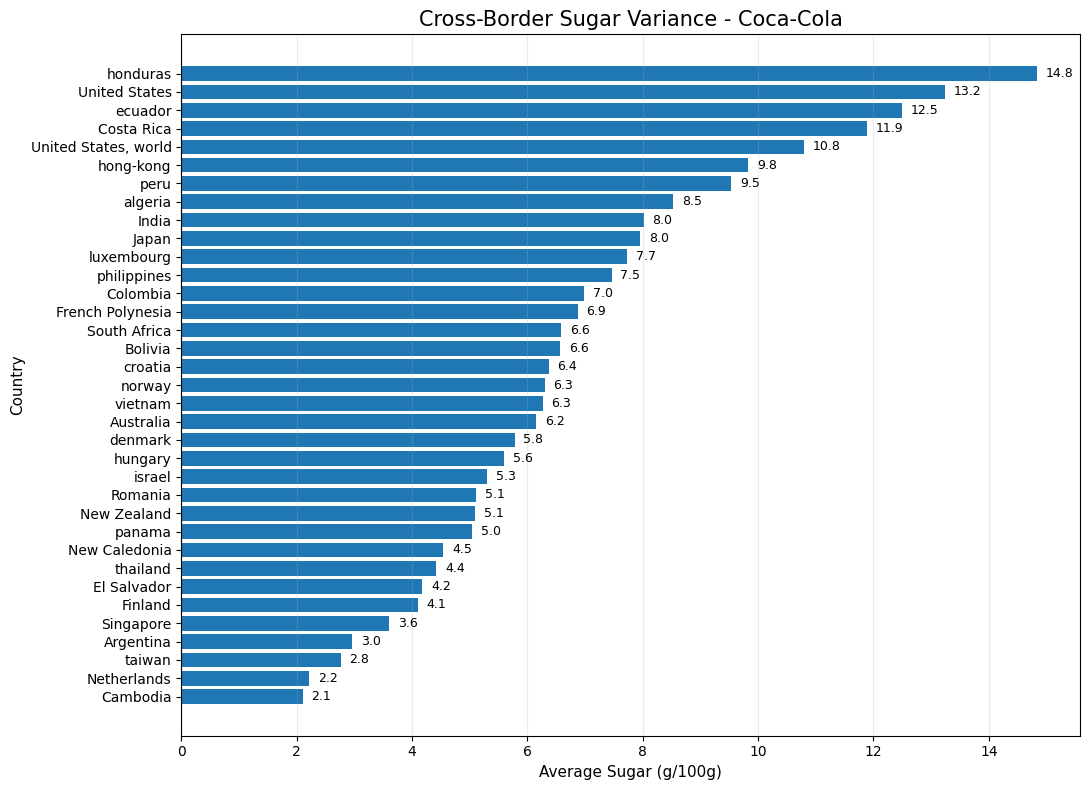

In [31]:
# Cross-Border Sugar Variance - Coca-Cola

df = pd.read_csv("datasets/coca-cola_from_dump.csv")

df['nutriments.sugars_100g'] = pd.to_numeric(
    df['nutriments.sugars_100g'], errors='coerce'
)

sugar_data = df[
    df['nutriments.sugars_100g'].notna() &
    df['countries_tags'].notna() &
    (df['countries_tags'].str.lower() != 'unknown')
].copy()

# Use countries with at least 5 products
country_counts = sugar_data['countries_tags'].value_counts()
valid_countries = country_counts[country_counts >= 5].index

sugar_by_country = (
    sugar_data[sugar_data['countries_tags'].isin(valid_countries)]
    .groupby('countries_tags')['nutriments.sugars_100g']
    .mean()
    .sort_values(ascending=True)
)

# Make country names readable
country_names = (
    sugar_by_country.index
    .str.replace('united-states', 'United States')
    .str.replace('new-zealand', 'New Zealand')
    .str.replace('south-africa', 'South Africa')
    .str.replace('costa-rica', 'Costa Rica')
    .str.replace('french-polynesia', 'French Polynesia')
    .str.replace('el-salvador', 'El Salvador')
    .str.replace('new-caledonia', 'New Caledonia')
    .str.replace('netherlands', 'Netherlands')
    .str.replace('singapore', 'Singapore')
    .str.replace('romania', 'Romania')
    .str.replace('india', 'India')
    .str.replace('japan', 'Japan')
    .str.replace('canada', 'Canada')
    .str.replace('australia', 'Australia')
    .str.replace('finland', 'Finland')
    .str.replace('argentina', 'Argentina')
    .str.replace('bolivia', 'Bolivia')
    .str.replace('colombia', 'Colombia')
    .str.replace('cambodia', 'Cambodia')
)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    country_names,
    sugar_by_country.values
)

plt.title(
    'Cross-Border Sugar Variance - Coca-Cola',
    fontsize=15
)

plt.xlabel('Average Sugar (g/100g)', fontsize=11)
plt.ylabel('Country', fontsize=11)

# Add values at the end of each bar
for bar, value in zip(bars, sugar_by_country.values):
    plt.text(
        value + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}',
        va='center',
        fontsize=9
    )

plt.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

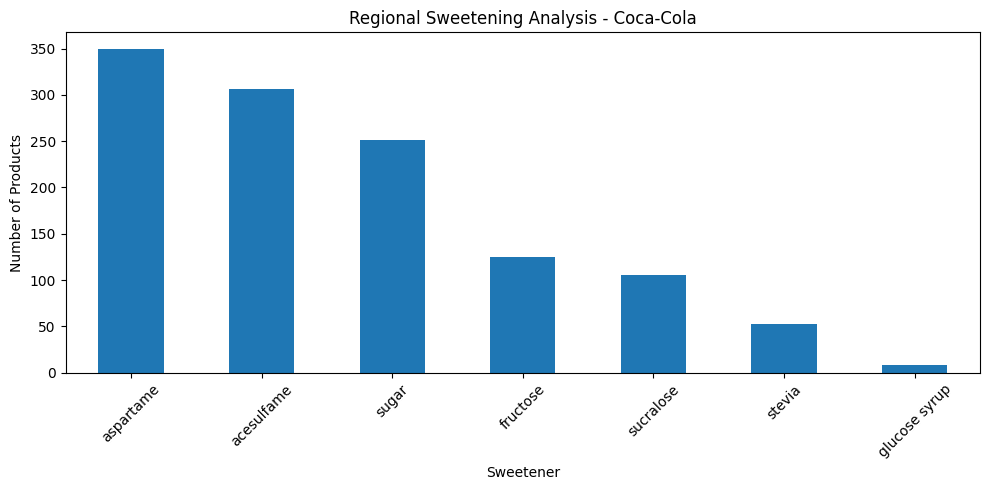

In [32]:
# Regional Sweetening Analysis - Coca-Cola

sweetener_data = df[
    df['ingredients_text'].notna() &
    (df['ingredients_text'].str.lower() != 'unknown')
].copy()

sweeteners = [
    'sugar', 'glucose syrup', 'fructose',
    'stevia', 'sucralose', 'aspartame', 'acesulfame'
]

sweetener_counts = {
    s: sweetener_data['ingredients_text'].str.lower().str.contains(
        s, na=False
    ).sum()
    for s in sweeteners
}

sweetener_counts = {k: v for k, v in sweetener_counts.items() if v > 0}

if sweetener_counts:
    plt.figure(figsize=(10, 5))
    pd.Series(sweetener_counts).sort_values(ascending=False).plot(kind='bar')
    plt.title('Regional Sweetening Analysis - Coca-Cola')
    plt.xlabel('Sweetener')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No usable sweetener information found.')

##### Nutri-Score Analysis

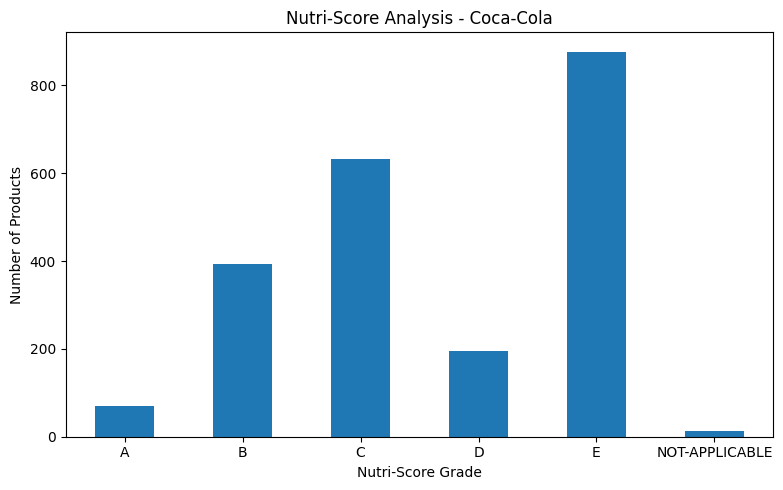

In [33]:
# Nutri-Score Analysis - Coca-Cola

nutri_data = df[
    df['nutriscore_grade'].notna() &
    (df['nutriscore_grade'].str.lower() != 'unknown')
].copy()

nutri_counts = (
    nutri_data['nutriscore_grade']
    .str.upper()
    .value_counts()
    .sort_index()
)

if not nutri_counts.empty:
    plt.figure(figsize=(8, 5))
    nutri_counts.plot(kind='bar')
    plt.title('Nutri-Score Analysis - Coca-Cola')
    plt.xlabel('Nutri-Score Grade')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('No usable Nutri-Score information found.')

### Brand: Fairlife

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

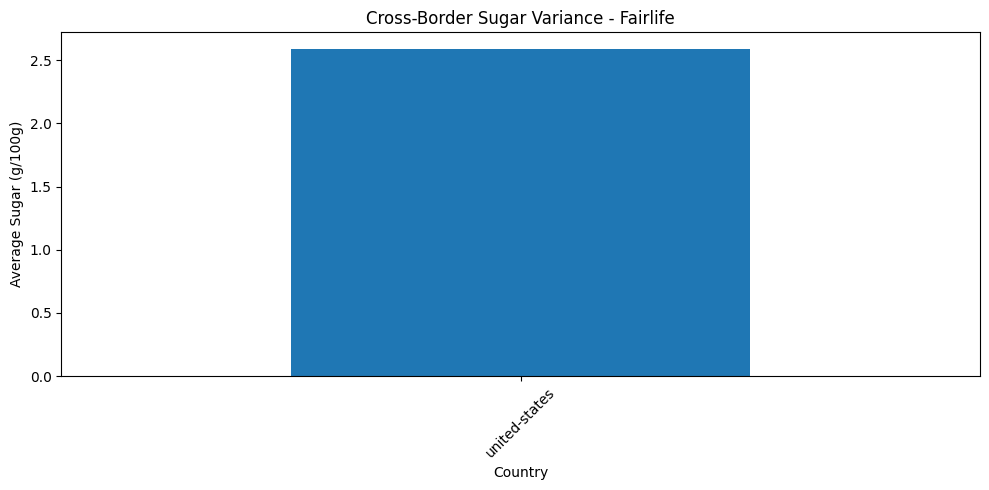

In [34]:
# Cross-Border Sugar Variance - Fairlife

df = pd.read_csv("datasets/fairlife_from_dump.csv")

df['nutriments.sugars_100g'] = pd.to_numeric(
    df['nutriments.sugars_100g'], errors='coerce'
)

sugar_data = df[
    df['nutriments.sugars_100g'].notna() &
    df['countries_tags'].notna() &
    (df['countries_tags'].str.lower() != 'unknown')
].copy()

# Use countries with at least 5 products
country_counts = sugar_data['countries_tags'].value_counts()
valid_countries = country_counts[country_counts >= 5].index

sugar_by_country = (
    sugar_data[sugar_data['countries_tags'].isin(valid_countries)]
    .groupby('countries_tags')['nutriments.sugars_100g']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sugar_by_country.plot(kind='bar')
plt.title('Cross-Border Sugar Variance - Fairlife')
plt.xlabel('Country')
plt.ylabel('Average Sugar (g/100g)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

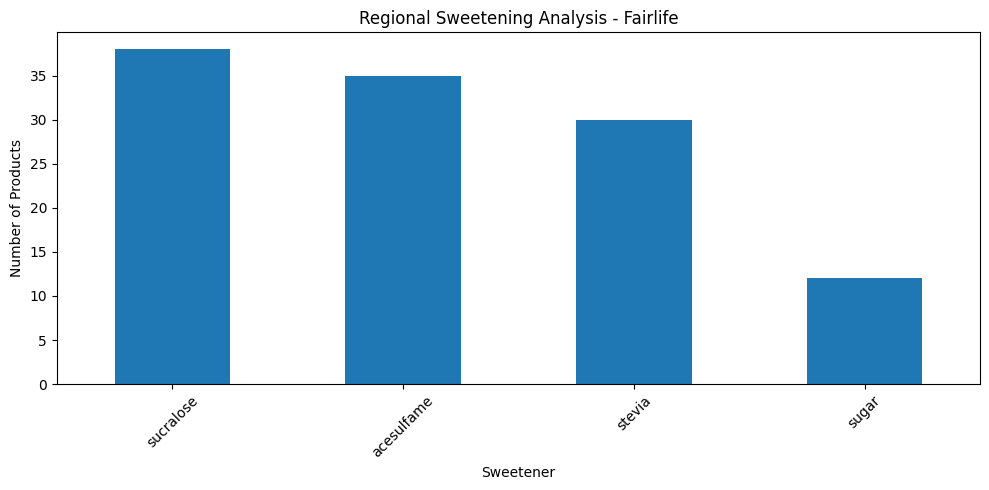

In [35]:
# Regional Sweetening Analysis - Fairlife

sweetener_data = df[
    df['ingredients_text'].notna() &
    (df['ingredients_text'].str.lower() != 'unknown')
].copy()

sweeteners = [
    'sugar', 'glucose syrup', 'fructose',
    'stevia', 'sucralose', 'aspartame', 'acesulfame'
]

sweetener_counts = {
    s: sweetener_data['ingredients_text'].str.lower().str.contains(
        s, na=False
    ).sum()
    for s in sweeteners
}

sweetener_counts = {k: v for k, v in sweetener_counts.items() if v > 0}

if sweetener_counts:
    plt.figure(figsize=(10, 5))
    pd.Series(sweetener_counts).sort_values(ascending=False).plot(kind='bar')
    plt.title('Regional Sweetening Analysis - Fairlife')
    plt.xlabel('Sweetener')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No usable sweetener information found.')

##### Nutri-Score Analysis

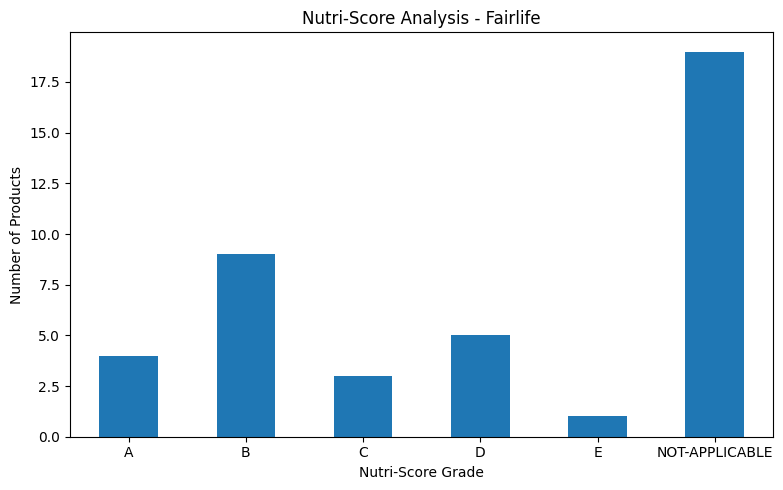

In [36]:
# Nutri-Score Analysis - Fairlife

nutri_data = df[
    df['nutriscore_grade'].notna() &
    (df['nutriscore_grade'].str.lower() != 'unknown')
].copy()

nutri_counts = (
    nutri_data['nutriscore_grade']
    .str.upper()
    .value_counts()
    .sort_index()
)

if not nutri_counts.empty:
    plt.figure(figsize=(8, 5))
    nutri_counts.plot(kind='bar')
    plt.title('Nutri-Score Analysis - Fairlife')
    plt.xlabel('Nutri-Score Grade')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('No usable Nutri-Score information found.')

### Brand: Fanta

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

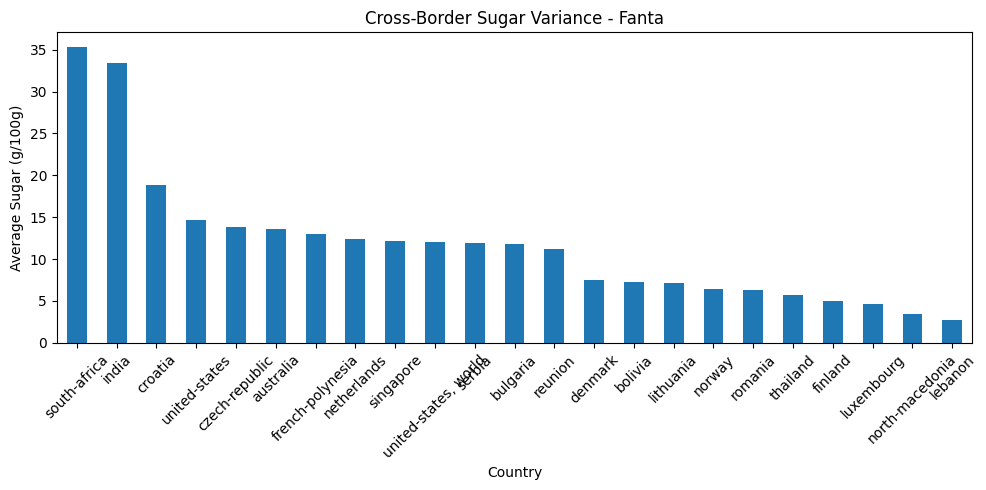

In [37]:
# Cross-Border Sugar Variance - Fanta

df = pd.read_csv("datasets/fanta_from_dump.csv")

df['nutriments.sugars_100g'] = pd.to_numeric(
    df['nutriments.sugars_100g'], errors='coerce'
)

sugar_data = df[
    df['nutriments.sugars_100g'].notna() &
    df['countries_tags'].notna() &
    (df['countries_tags'].str.lower() != 'unknown')
].copy()

# Use countries with at least 5 products
country_counts = sugar_data['countries_tags'].value_counts()
valid_countries = country_counts[country_counts >= 5].index

sugar_by_country = (
    sugar_data[sugar_data['countries_tags'].isin(valid_countries)]
    .groupby('countries_tags')['nutriments.sugars_100g']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sugar_by_country.plot(kind='bar')
plt.title('Cross-Border Sugar Variance - Fanta')
plt.xlabel('Country')
plt.ylabel('Average Sugar (g/100g)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

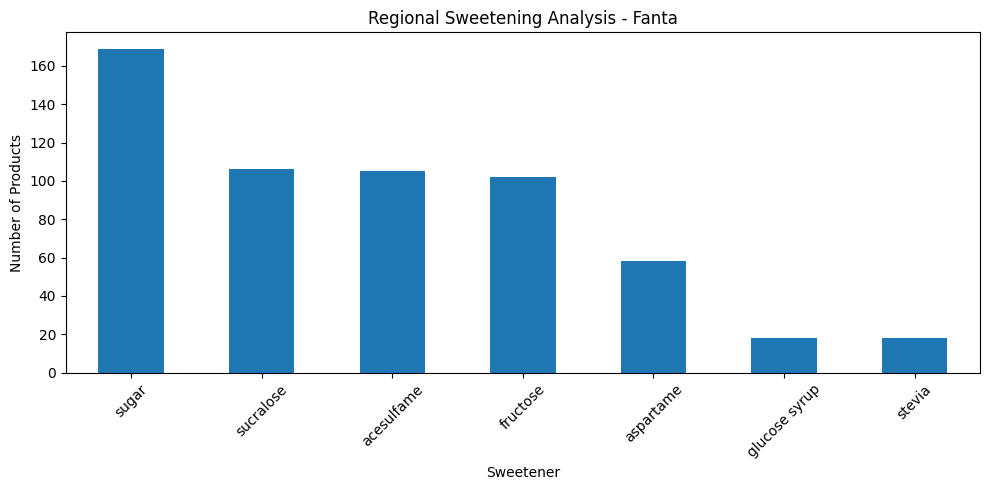

In [38]:
# Regional Sweetening Analysis - Fanta

sweetener_data = df[
    df['ingredients_text'].notna() &
    (df['ingredients_text'].str.lower() != 'unknown')
].copy()

sweeteners = [
    'sugar', 'glucose syrup', 'fructose',
    'stevia', 'sucralose', 'aspartame', 'acesulfame'
]

sweetener_counts = {
    s: sweetener_data['ingredients_text'].str.lower().str.contains(
        s, na=False
    ).sum()
    for s in sweeteners
}

sweetener_counts = {k: v for k, v in sweetener_counts.items() if v > 0}

if sweetener_counts:
    plt.figure(figsize=(10, 5))
    pd.Series(sweetener_counts).sort_values(ascending=False).plot(kind='bar')
    plt.title('Regional Sweetening Analysis - Fanta')
    plt.xlabel('Sweetener')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No usable sweetener information found.')

##### Nutri-Score Analysis

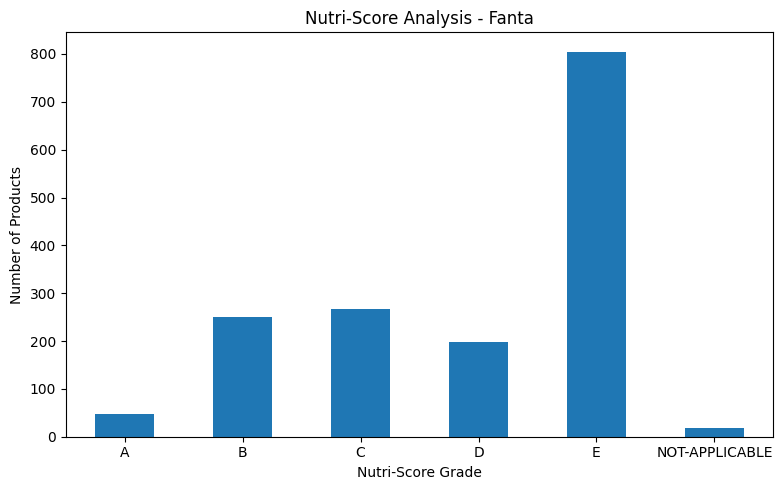

In [39]:
# Nutri-Score Analysis - Fanta

nutri_data = df[
    df['nutriscore_grade'].notna() &
    (df['nutriscore_grade'].str.lower() != 'unknown')
].copy()

nutri_counts = (
    nutri_data['nutriscore_grade']
    .str.upper()
    .value_counts()
    .sort_index()
)

if not nutri_counts.empty:
    plt.figure(figsize=(8, 5))
    nutri_counts.plot(kind='bar')
    plt.title('Nutri-Score Analysis - Fanta')
    plt.xlabel('Nutri-Score Grade')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('No usable Nutri-Score information found.')

### Brand: Maaza

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

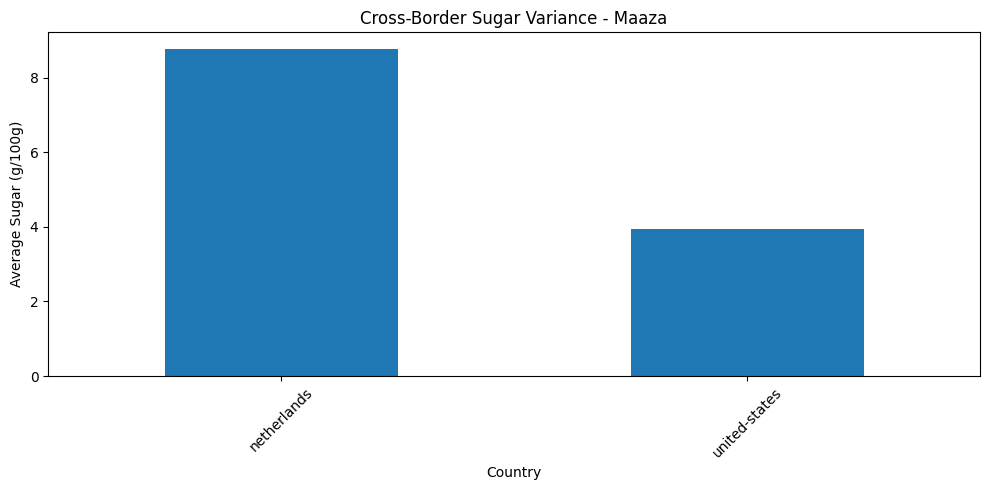

In [40]:
# Cross-Border Sugar Variance - Maaza

df = pd.read_csv("datasets/maaza_from_dump.csv")

df['nutriments.sugars_100g'] = pd.to_numeric(
    df['nutriments.sugars_100g'], errors='coerce'
)

sugar_data = df[
    df['nutriments.sugars_100g'].notna() &
    df['countries_tags'].notna() &
    (df['countries_tags'].str.lower() != 'unknown')
].copy()

# Use countries with at least 5 products
country_counts = sugar_data['countries_tags'].value_counts()
valid_countries = country_counts[country_counts >= 5].index

sugar_by_country = (
    sugar_data[sugar_data['countries_tags'].isin(valid_countries)]
    .groupby('countries_tags')['nutriments.sugars_100g']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sugar_by_country.plot(kind='bar')
plt.title('Cross-Border Sugar Variance - Maaza')
plt.xlabel('Country')
plt.ylabel('Average Sugar (g/100g)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

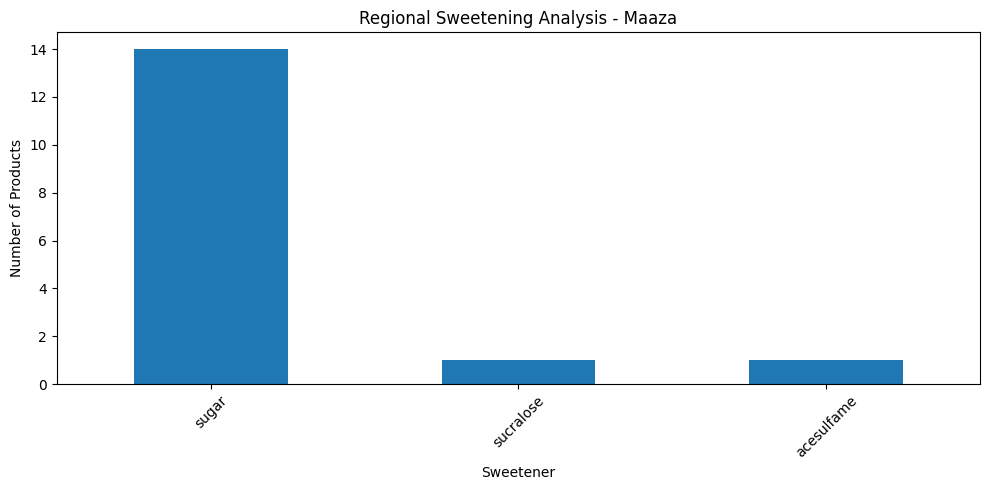

In [41]:
# Regional Sweetening Analysis - Maaza

sweetener_data = df[
    df['ingredients_text'].notna() &
    (df['ingredients_text'].str.lower() != 'unknown')
].copy()

sweeteners = [
    'sugar', 'glucose syrup', 'fructose',
    'stevia', 'sucralose', 'aspartame', 'acesulfame'
]

sweetener_counts = {
    s: sweetener_data['ingredients_text'].str.lower().str.contains(
        s, na=False
    ).sum()
    for s in sweeteners
}

sweetener_counts = {k: v for k, v in sweetener_counts.items() if v > 0}

if sweetener_counts:
    plt.figure(figsize=(10, 5))
    pd.Series(sweetener_counts).sort_values(ascending=False).plot(kind='bar')
    plt.title('Regional Sweetening Analysis - Maaza')
    plt.xlabel('Sweetener')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No usable sweetener information found.')

##### Nutri-Score Analysis

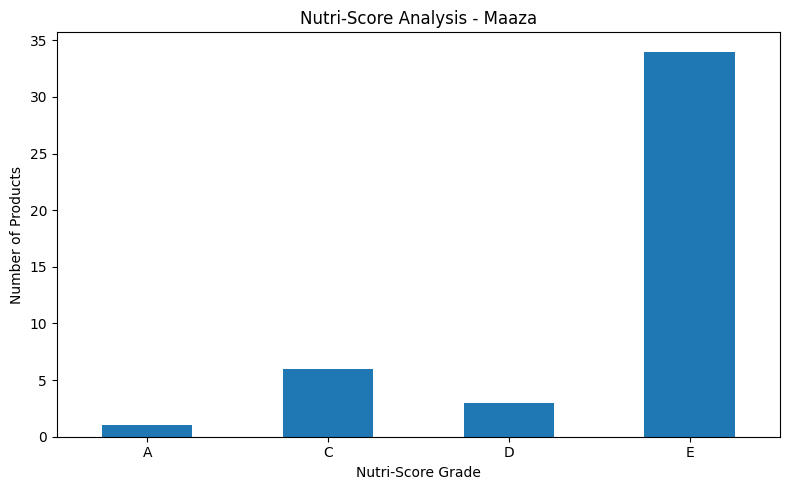

In [42]:
# Nutri-Score Analysis - Maaza

nutri_data = df[
    df['nutriscore_grade'].notna() &
    (df['nutriscore_grade'].str.lower() != 'unknown')
].copy()

nutri_counts = (
    nutri_data['nutriscore_grade']
    .str.upper()
    .value_counts()
    .sort_index()
)

if not nutri_counts.empty:
    plt.figure(figsize=(8, 5))
    nutri_counts.plot(kind='bar')
    plt.title('Nutri-Score Analysis - Maaza')
    plt.xlabel('Nutri-Score Grade')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('No usable Nutri-Score information found.')

### Brand: Minute Maid

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

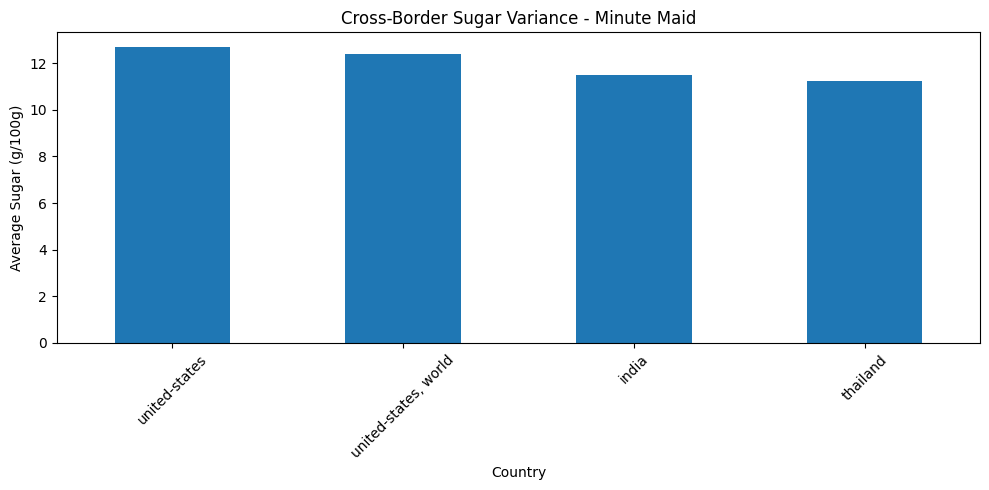

In [43]:
# Cross-Border Sugar Variance - Minute Maid

df = pd.read_csv("datasets/minute maid_from_dump.csv")

df['nutriments.sugars_100g'] = pd.to_numeric(
    df['nutriments.sugars_100g'], errors='coerce'
)

sugar_data = df[
    df['nutriments.sugars_100g'].notna() &
    df['countries_tags'].notna() &
    (df['countries_tags'].str.lower() != 'unknown')
].copy()

# Use countries with at least 5 products
country_counts = sugar_data['countries_tags'].value_counts()
valid_countries = country_counts[country_counts >= 5].index

sugar_by_country = (
    sugar_data[sugar_data['countries_tags'].isin(valid_countries)]
    .groupby('countries_tags')['nutriments.sugars_100g']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sugar_by_country.plot(kind='bar')
plt.title('Cross-Border Sugar Variance - Minute Maid')
plt.xlabel('Country')
plt.ylabel('Average Sugar (g/100g)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

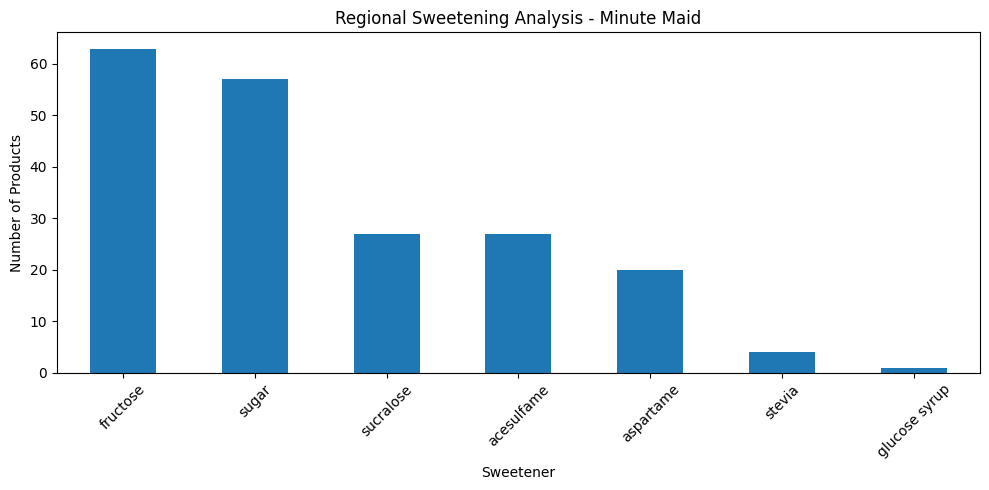

In [44]:
# Regional Sweetening Analysis - Minute Maid

sweetener_data = df[
    df['ingredients_text'].notna() &
    (df['ingredients_text'].str.lower() != 'unknown')
].copy()

sweeteners = [
    'sugar', 'glucose syrup', 'fructose',
    'stevia', 'sucralose', 'aspartame', 'acesulfame'
]

sweetener_counts = {
    s: sweetener_data['ingredients_text'].str.lower().str.contains(
        s, na=False
    ).sum()
    for s in sweeteners
}

sweetener_counts = {k: v for k, v in sweetener_counts.items() if v > 0}

if sweetener_counts:
    plt.figure(figsize=(10, 5))
    pd.Series(sweetener_counts).sort_values(ascending=False).plot(kind='bar')
    plt.title('Regional Sweetening Analysis - Minute Maid')
    plt.xlabel('Sweetener')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No usable sweetener information found.')

##### Nutri-Score Analysis

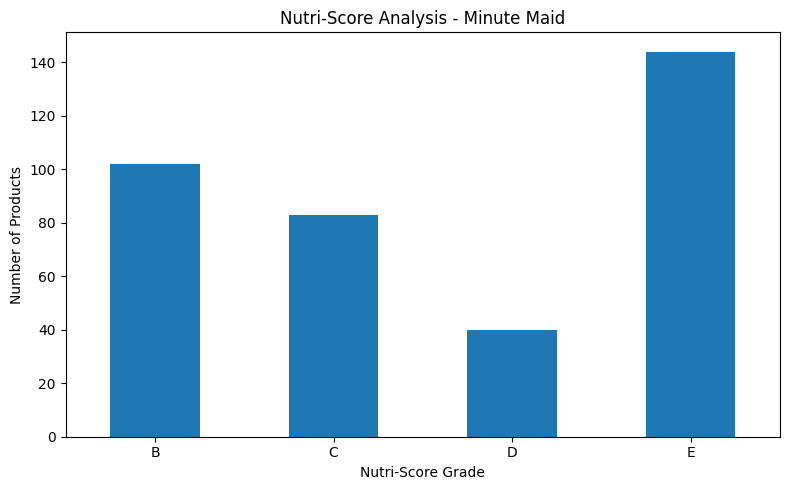

In [45]:
# Nutri-Score Analysis - Minute Maid

nutri_data = df[
    df['nutriscore_grade'].notna() &
    (df['nutriscore_grade'].str.lower() != 'unknown')
].copy()

nutri_counts = (
    nutri_data['nutriscore_grade']
    .str.upper()
    .value_counts()
    .sort_index()
)

if not nutri_counts.empty:
    plt.figure(figsize=(8, 5))
    nutri_counts.plot(kind='bar')
    plt.title('Nutri-Score Analysis - Minute Maid')
    plt.xlabel('Nutri-Score Grade')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('No usable Nutri-Score information found.')

### Brand: Schweppes

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

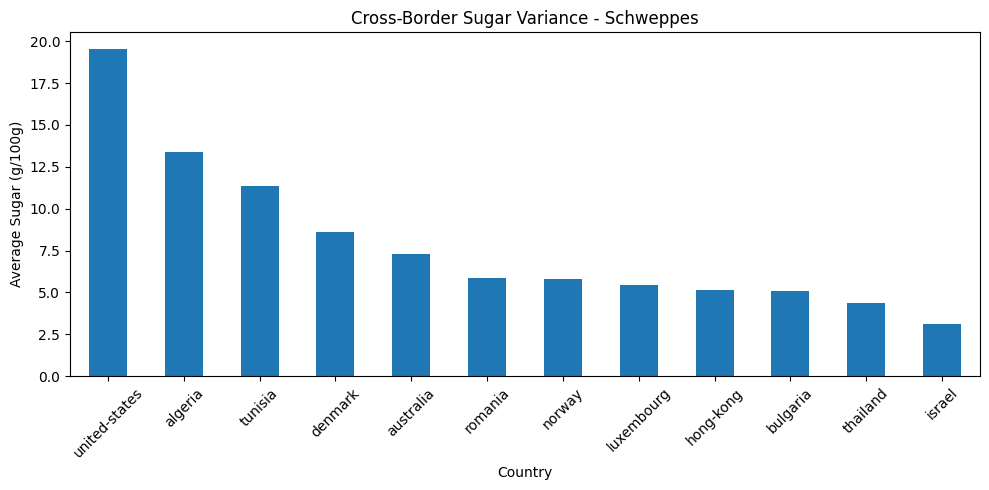

In [46]:
# Cross-Border Sugar Variance - Schweppes

df = pd.read_csv("datasets/schweppes_from_dump.csv")

df['nutriments.sugars_100g'] = pd.to_numeric(
    df['nutriments.sugars_100g'], errors='coerce'
)

sugar_data = df[
    df['nutriments.sugars_100g'].notna() &
    df['countries_tags'].notna() &
    (df['countries_tags'].str.lower() != 'unknown')
].copy()

# Use countries with at least 5 products
country_counts = sugar_data['countries_tags'].value_counts()
valid_countries = country_counts[country_counts >= 5].index

sugar_by_country = (
    sugar_data[sugar_data['countries_tags'].isin(valid_countries)]
    .groupby('countries_tags')['nutriments.sugars_100g']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sugar_by_country.plot(kind='bar')
plt.title('Cross-Border Sugar Variance - Schweppes')
plt.xlabel('Country')
plt.ylabel('Average Sugar (g/100g)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

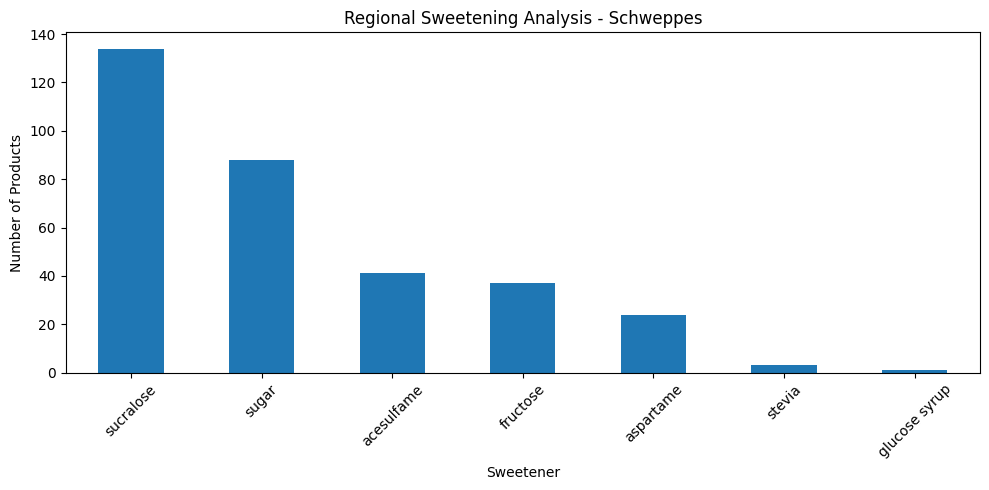

In [47]:
# Regional Sweetening Analysis - Schweppes

sweetener_data = df[
    df['ingredients_text'].notna() &
    (df['ingredients_text'].str.lower() != 'unknown')
].copy()

sweeteners = [
    'sugar', 'glucose syrup', 'fructose',
    'stevia', 'sucralose', 'aspartame', 'acesulfame'
]

sweetener_counts = {
    s: sweetener_data['ingredients_text'].str.lower().str.contains(
        s, na=False
    ).sum()
    for s in sweeteners
}

sweetener_counts = {k: v for k, v in sweetener_counts.items() if v > 0}

if sweetener_counts:
    plt.figure(figsize=(10, 5))
    pd.Series(sweetener_counts).sort_values(ascending=False).plot(kind='bar')
    plt.title('Regional Sweetening Analysis - Schweppes')
    plt.xlabel('Sweetener')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No usable sweetener information found.')

##### Nutri-Score Analysis

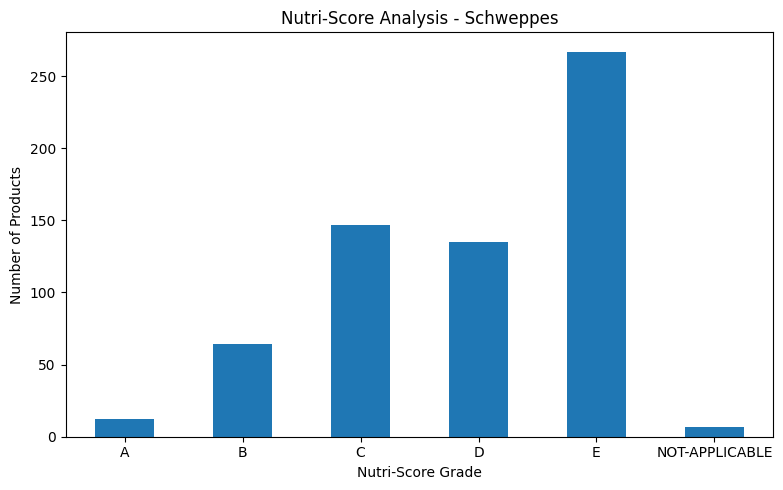

In [48]:
# Nutri-Score Analysis - Schweppes

nutri_data = df[
    df['nutriscore_grade'].notna() &
    (df['nutriscore_grade'].str.lower() != 'unknown')
].copy()

nutri_counts = (
    nutri_data['nutriscore_grade']
    .str.upper()
    .value_counts()
    .sort_index()
)

if not nutri_counts.empty:
    plt.figure(figsize=(8, 5))
    nutri_counts.plot(kind='bar')
    plt.title('Nutri-Score Analysis - Schweppes')
    plt.xlabel('Nutri-Score Grade')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('No usable Nutri-Score information found.')

### Brand: Sprite

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

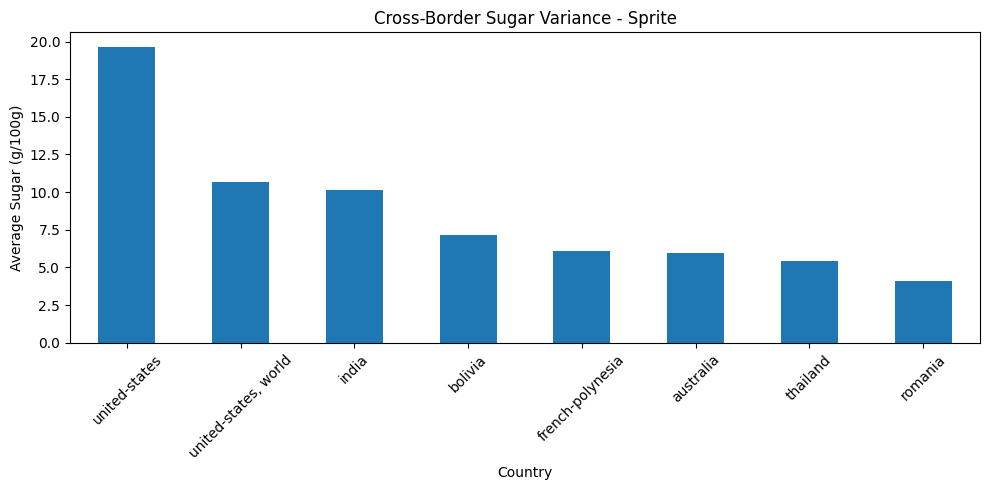

In [49]:
# Cross-Border Sugar Variance - Sprite

df = pd.read_csv("datasets/sprite_from_dump.csv")

df['nutriments.sugars_100g'] = pd.to_numeric(
    df['nutriments.sugars_100g'], errors='coerce'
)

sugar_data = df[
    df['nutriments.sugars_100g'].notna() &
    df['countries_tags'].notna() &
    (df['countries_tags'].str.lower() != 'unknown')
].copy()

# Use countries with at least 5 products
country_counts = sugar_data['countries_tags'].value_counts()
valid_countries = country_counts[country_counts >= 5].index

sugar_by_country = (
    sugar_data[sugar_data['countries_tags'].isin(valid_countries)]
    .groupby('countries_tags')['nutriments.sugars_100g']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sugar_by_country.plot(kind='bar')
plt.title('Cross-Border Sugar Variance - Sprite')
plt.xlabel('Country')
plt.ylabel('Average Sugar (g/100g)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

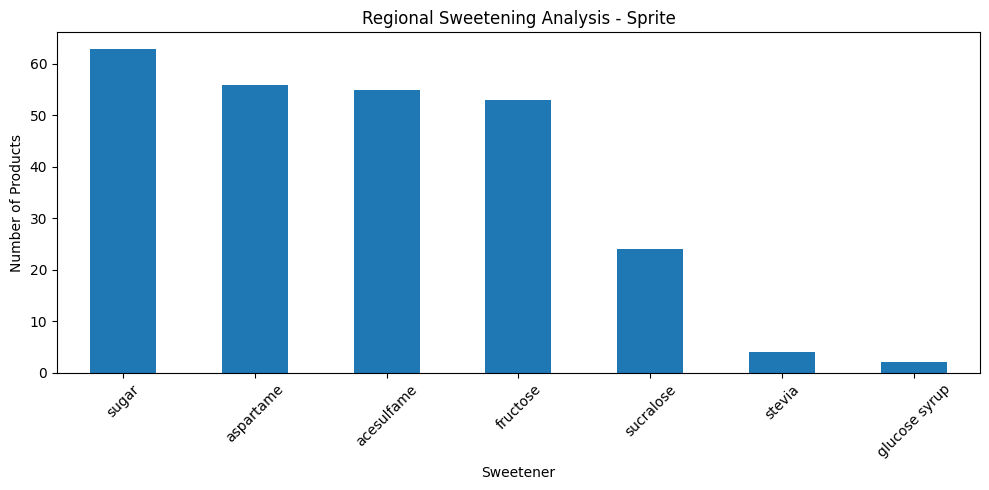

In [50]:
# Regional Sweetening Analysis - Sprite

sweetener_data = df[
    df['ingredients_text'].notna() &
    (df['ingredients_text'].str.lower() != 'unknown')
].copy()

sweeteners = [
    'sugar', 'glucose syrup', 'fructose',
    'stevia', 'sucralose', 'aspartame', 'acesulfame'
]

sweetener_counts = {
    s: sweetener_data['ingredients_text'].str.lower().str.contains(
        s, na=False
    ).sum()
    for s in sweeteners
}

sweetener_counts = {k: v for k, v in sweetener_counts.items() if v > 0}

if sweetener_counts:
    plt.figure(figsize=(10, 5))
    pd.Series(sweetener_counts).sort_values(ascending=False).plot(kind='bar')
    plt.title('Regional Sweetening Analysis - Sprite')
    plt.xlabel('Sweetener')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No usable sweetener information found.')

##### Nutri-Score Analysis

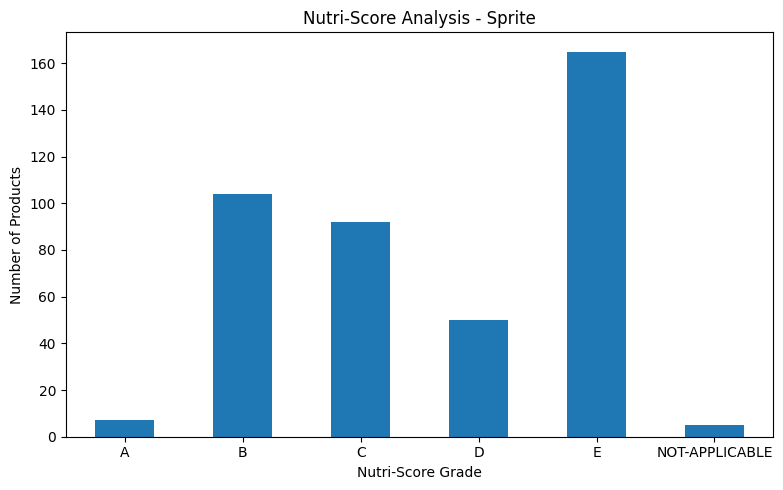

In [51]:
# Nutri-Score Analysis - Sprite

nutri_data = df[
    df['nutriscore_grade'].notna() &
    (df['nutriscore_grade'].str.lower() != 'unknown')
].copy()

nutri_counts = (
    nutri_data['nutriscore_grade']
    .str.upper()
    .value_counts()
    
    .sort_index()
)

if not nutri_counts.empty:
    plt.figure(figsize=(8, 5))
    nutri_counts.plot(kind='bar')
    plt.title('Nutri-Score Analysis - Sprite')
    plt.xlabel('Nutri-Score Grade')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('No usable Nutri-Score information found.')

### Brand: Topo Chico

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

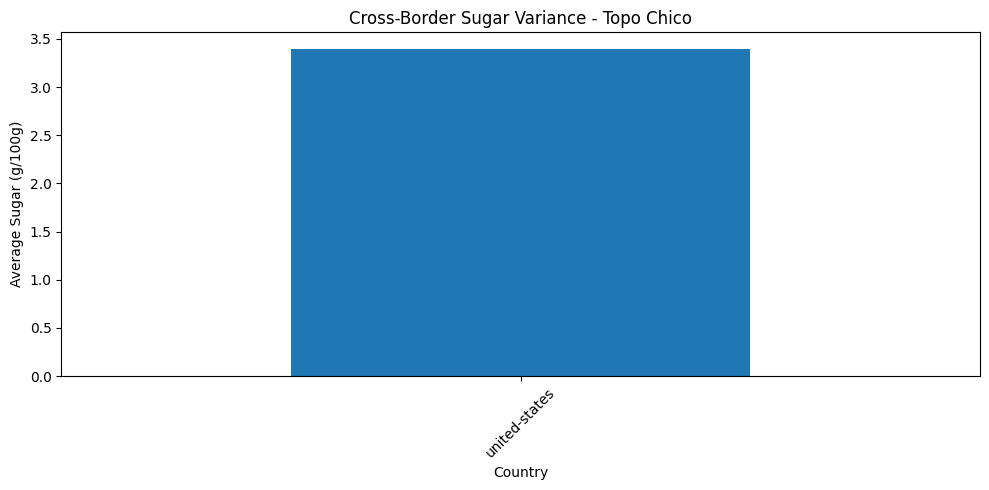

In [52]:
# Cross-Border Sugar Variance - Topo Chico

df = pd.read_csv("datasets/topo chico_from_dump.csv")

df['nutriments.sugars_100g'] = pd.to_numeric(
    df['nutriments.sugars_100g'], errors='coerce'
)

sugar_data = df[
    df['nutriments.sugars_100g'].notna() &
    df['countries_tags'].notna() &
    (df['countries_tags'].str.lower() != 'unknown')
].copy()

# Use countries with at least 5 products
country_counts = sugar_data['countries_tags'].value_counts()
valid_countries = country_counts[country_counts >= 5].index

sugar_by_country = (
    sugar_data[sugar_data['countries_tags'].isin(valid_countries)]
    .groupby('countries_tags')['nutriments.sugars_100g']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sugar_by_country.plot(kind='bar')
plt.title('Cross-Border Sugar Variance - Topo Chico')
plt.xlabel('Country')
plt.ylabel('Average Sugar (g/100g)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

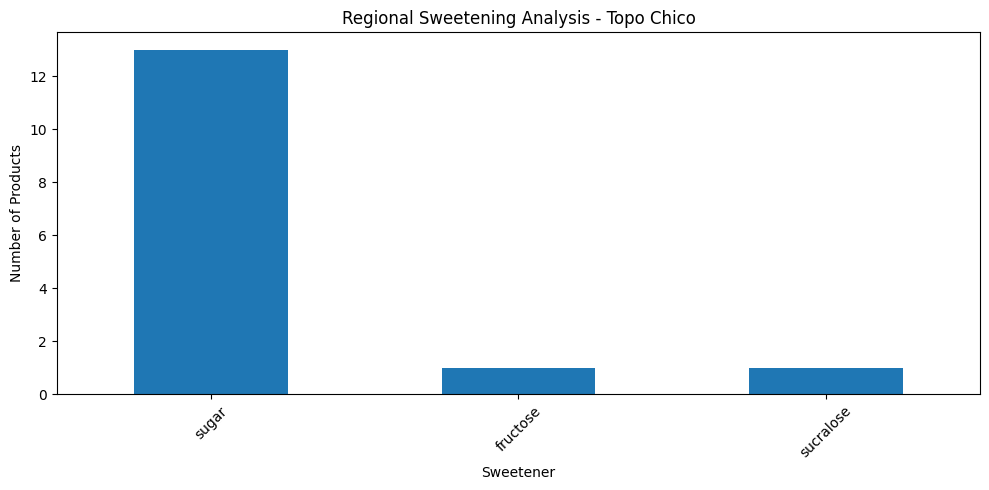

In [53]:
# Regional Sweetening Analysis - Topo Chico

sweetener_data = df[
    df['ingredients_text'].notna() &
    (df['ingredients_text'].str.lower() != 'unknown')
].copy()

sweeteners = [
    'sugar', 'glucose syrup', 'fructose',
    'stevia', 'sucralose', 'aspartame', 'acesulfame'
]

sweetener_counts = {
    s: sweetener_data['ingredients_text'].str.lower().str.contains(
        s, na=False
    ).sum()
    for s in sweeteners
}

sweetener_counts = {k: v for k, v in sweetener_counts.items() if v > 0}

if sweetener_counts:
    plt.figure(figsize=(10, 5))
    pd.Series(sweetener_counts).sort_values(ascending=False).plot(kind='bar')
    plt.title('Regional Sweetening Analysis - Topo Chico')
    plt.xlabel('Sweetener')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No usable sweetener information found.')

##### Nutri-Score Analysis

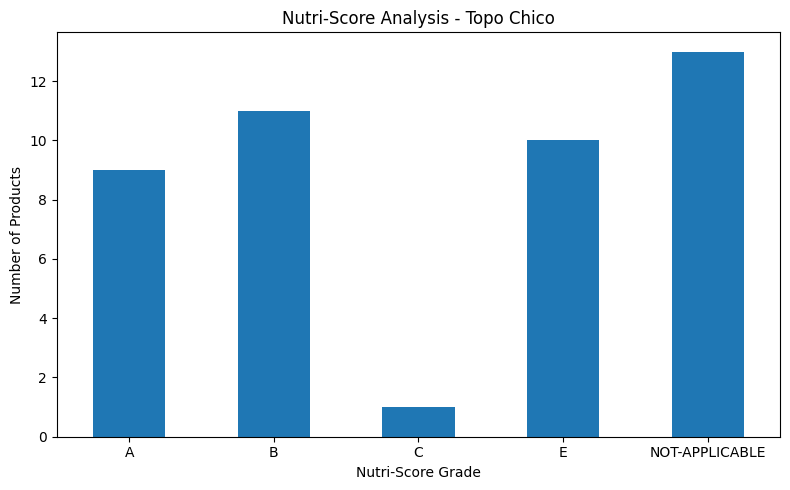

In [54]:
# Nutri-Score Analysis - Topo Chico

nutri_data = df[
    df['nutriscore_grade'].notna() &
    (df['nutriscore_grade'].str.lower() != 'unknown')
].copy()

nutri_counts = (
    nutri_data['nutriscore_grade']
    .str.upper()
    .value_counts()
    .sort_index()
)

if not nutri_counts.empty:
    plt.figure(figsize=(8, 5))
    nutri_counts.plot(kind='bar')
    plt.title('Nutri-Score Analysis - Topo Chico')
    plt.xlabel('Nutri-Score Grade')
    plt.ylabel('Number of Products')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('No usable Nutri-Score information found.')